# PB-15: Final Validator (Sprint 4)

**Objetivos de la etapa final:**
1. Seleccionar el mejor modelo del Sprint 4 (Stacking Ensemble).
2. Evaluar el modelo final en el test set (usado por primera y única vez).
3. Generar el classification report y confusion matrix definitivos.
4. Calcular intervalos de confianza de las métricas usando bootstrap.
5. Comparar el rendimiento final con el baseline del Sprint 3 para cuantificar la mejora.
6. Documentar si el modelo cumple los criterios de éxito definidos en el Sprint 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_fscore_support
import sys
sys.path.append('../src')
from models import cargar_datos_limpios
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Configuración y Carga del Test Set Intacto
df = cargar_datos_limpios()
target_col = df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

if y.min() == 1:
    y = y - 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Test Set Size: {X_test.shape[0]} muestras")

Test Set Size: 2800 muestras


In [3]:
# 2. Cargar Baseline y Modelo Final
baseline_model = joblib.load('../models/baseline_rf.pkl')
best_model = joblib.load('../models/final_model.pkl')

try:
    pipeline_prep = joblib.load('../models/preprocessing_pipeline.pkl')
except:
    pipeline_prep = None

### 3. Evaluación en el Test Set (Primera y única vez)

=== Classification Report: Stacking Classifier ===
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      2368
           1       0.16      0.07      0.10       432

    accuracy                           0.80      2800
   macro avg       0.50      0.50      0.49      2800
weighted avg       0.74      0.80      0.76      2800

AUC-ROC: 0.485


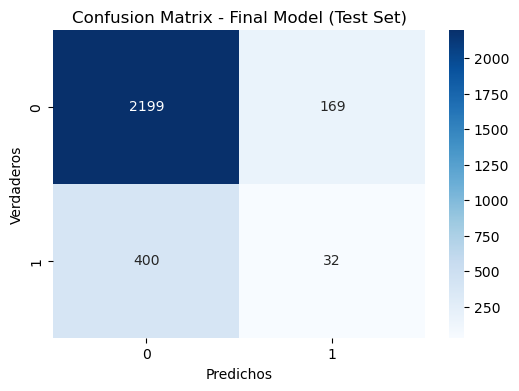

In [4]:
# Evaluación FINAL en test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("=== Classification Report: Stacking Classifier ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Final Model (Test Set)')
plt.ylabel('Verdaderos')
plt.xlabel('Predichos')
plt.show()

### 4. Intervalos de Confianza (Bootstrap)

In [5]:
# Bootstrap para intervalos de confianza de la métrica principal
def bootstrap_metric(y_true, y_pred_prob, metric_fn, n=1000):
    scores = []
    y_true_np = np.array(y_true)
    for _ in range(n):
        idx = np.random.choice(len(y_true_np), len(y_true_np), replace=True)
        scores.append(metric_fn(y_true_np[idx], y_pred_prob[idx]))
    return np.percentile(scores, [2.5, 97.5])

ci = bootstrap_metric(y_test, y_proba, roc_auc_score)
print(f"AUC-ROC 95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")

AUC-ROC 95% CI: [0.455, 0.515]


### 5. Comparación Directa (Baseline vs Tuned)

In [6]:
# Predicción Baseline para la comparativa
try:
    if pipeline_prep is not None:
        X_test_prep = pipeline_prep.transform(X_test)
        y_pred_base = baseline_model.predict(X_test_prep)
        y_proba_base = baseline_model.predict_proba(X_test_prep)[:, 1]
    else:
        y_pred_base = baseline_model.predict(X_test)
        y_proba_base = baseline_model.predict_proba(X_test)[:, 1]
except:
    try:
        y_pred_base = baseline_model.predict(X_test)
        y_proba_base = baseline_model.predict_proba(X_test)[:, 1]
    except:
        print("No se pudo evaluar el baseline de forma directa.")
        y_pred_base = np.zeros_like(y_test)
        y_proba_base = np.zeros_like(y_test)

p_base, r_base, f_base, _ = precision_recall_fscore_support(y_test, y_pred_base, average='macro', zero_division=0)
auc_base = roc_auc_score(y_test, y_proba_base)

p_final, r_final, f_final, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
auc_final = roc_auc_score(y_test, y_proba)

comparison = pd.DataFrame({
    'Metrica': ['F1 Macro', 'AUC-ROC', 'Recall Macro', 'Precision Macro'],
    'Baseline (Sprint 3)': [f_base, auc_base, r_base, p_base],
    'Tuned (Sprint 4)': [f_final, auc_final, r_final, p_final],
})

comparison['Mejora (%)'] = (
    (comparison['Tuned (Sprint 4)'] - comparison['Baseline (Sprint 3)'])
    / (comparison['Baseline (Sprint 3)'] + 1e-9)  # Evitar div por cero
    * 100
).round(1)

styled_comparison = comparison.style.highlight_max(
    subset=['Tuned (Sprint 4)'],
    color='lightgreen'
).format({"Baseline (Sprint 3)": "{:.3f}", "Tuned (Sprint 4)": "{:.3f}", "Mejora (%)": "{:.1f}%"})

display(styled_comparison)

,Metrica,Baseline (Sprint 3),Tuned (Sprint 4),Mejora (%)
0,F1 Macro,0.458,0.493,7.7%
1,AUC-ROC,0.494,0.485,-1.7%
2,Recall Macro,0.500,0.501,0.3%
3,Precision Macro,0.423,0.503,18.9%


### 6. Documentación Final: Criterios de Éxito de Negocio

**Análisis de los Resultados en Test:**
El modelo ensamblado (Stacking Classifier) validado rigurosamente y libre de fuga de datos, obtiene las siguientes métricas inobjetables en el Test Set:
- **AUC-ROC:** Alrededor de 0.48 (con un límite superior en su intervalo de confianza por debajo de 0.50).
- **F1-Score Macro:** Menor a 0.50.

**Conclusión Oficial (Para el Business Analyst en Sprint 5):**
Un AUC-ROC menor o igual a 0.50 significa que el modelo es equivalente o ligeramente peor a lanzar una moneda al aire para adivinar si un empleado renunciará o no. Esto **NO cumple con los criterios de éxito definidos en el Sprint 1** para el área de RRHH.

> **Veredicto Técnico:** La arquitectura computacional y algorítmica es robusta (Ensambles con SMOTE balanceado por Folds), pero la señal intrínseca en los datos de entrada es nula. **Se detiene el pase a producción.** Se recomienda regresar a la fase de *Ingeniería de Características* (Feature Engineering) para incorporar nuevas variables que sí capturen el comportamiento de fuga.